# **Import Everything**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import floor
import matplotlib.ticker as mtick
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
print('Everything is Imported Boss')

Everything is Imported Boss


# **Data Exploration**

## **Load the Data**

In [2]:
file_path = input("Enter the file Path: ")
df = pd.read_csv(file_path)
print("Data Loaded Baby")

Data Loaded Baby


## **Exploration**

In [3]:
print(f'The dataset have {df.shape[0]} Rows and {df.shape[1]} columns with {df.duplicated().sum()} Duplicates')

The dataset have 30300 Rows and 10 columns with 295 Duplicates


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30300 entries, 0 to 30299
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   pm25            29700 non-null  str    
 1   pm10            29692 non-null  float64
 2   no2_ppb         29693 non-null  float64
 3   co_ppm          29691 non-null  float64
 4   so2_ppb         29696 non-null  float64
 5   o3_ppb          29695 non-null  float64
 6   wind_speed_kmh  29692 non-null  float64
 7   humidity_pct    29690 non-null  float64
 8   temperature_c   29695 non-null  float64
 9   aqi             29694 non-null  float64
dtypes: float64(9), str(1)
memory usage: 2.5 MB


In [5]:
df.sample(5)

,pm25,pm10,no2_ppb,co_ppm,so2_ppb,o3_ppb,wind_speed_kmh,humidity_pct,temperature_c,aqi
10705,42.58,96.00,33.25,NaN,11.58,57.49,14.58,60.39,34.32,92.66
29283,106.73,155.91,124.38,2.72,17.11,68.86,4.32,46.60,33.98,164.03
16588,30.07,90.47,47.90,1.09,18.42,43.37,6.39,60.37,21.55,98.75
9627,46.99,75.79,52.49,0.99,16.50,43.62,4.60,50.26,30.65,113.56
30163,40.25,75.45,58.12,1.17,15.76,44.62,8.97,65.60,30.06,117.16


In [6]:
df.describe()

,pm10,no2_ppb,co_ppm,so2_ppb,o3_ppb,wind_speed_kmh,humidity_pct,temperature_c,aqi
count,29692.000000,29693.000000,29691.000000,29696.000000,29695.000000,29692.000000,29690.000000,29695.000000,29694.000000
mean,129.693071,62.675658,1.844811,18.907754,45.789591,9.971470,57.269537,28.695675,150.302440
std,97.188619,40.471651,1.295335,16.251000,15.322394,6.006352,12.149996,6.338512,91.260187
min,5.420000,-1.670000,-1.000000,-0.530000,9.650000,0.000000,13.870000,-50.000000,15.660000
25%,32.590000,21.120000,0.540000,4.470000,32.880000,5.120000,48.680000,24.180000,53.882500
50%,94.125000,51.180000,1.430000,13.890000,42.780000,8.420000,57.280000,28.980000,126.500000
75%,186.472500,97.730000,3.020000,25.210000,58.665000,14.030000,65.867500,33.280000,219.380000
max,407.720000,175.180000,5.720000,74.460000,95.300000,33.980000,150.000000,50.870000,999.000000


In [7]:
print("NaN values in the dataset is: ")
print(df.isna().sum())

NaN values in the dataset is: 
pm25              600
pm10              608
no2_ppb           607
co_ppm            609
so2_ppb           604
o3_ppb            605
wind_speed_kmh    608
humidity_pct      610
temperature_c     605
aqi               606
dtype: int64


# **Data Cleaning**

## **Create Copy**

In [8]:
df_copy = df.copy()
print('Copy Created Baby')

Copy Created Baby


## **Datatype**

In [9]:
df_copy['pm25'] = df_copy['pm25'].replace('_err','',regex=True).astype('float')

## **Impossible Values**

In [10]:
Columns = ['pm25','no2_ppb','co_ppm','so2_ppb']
for col in Columns:
    df_copy.loc[df_copy[col]<0,col] = np.nan
df_copy.loc[df_copy['humidity_pct']>100,'humidity_pct'] = np.nan

## **Outliers**

In [11]:
columns = ['pm25','pm10','no2_ppb','aqi','co_ppm','o3_ppb']

for col in columns:
    Q1 = df_copy[col].quantile(0.25)
    Q3 = df_copy[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_copy.loc[df_copy[col] < lower, col] = np.nan
    df_copy.loc[df_copy[col] > upper, col] = np.nan

print("Outliers Handled ✅")

Outliers Handled ✅


In [12]:
df_copy.describe()

,pm25,pm10,no2_ppb,co_ppm,so2_ppb,o3_ppb,wind_speed_kmh,humidity_pct,temperature_c,aqi
count,29693.000000,29692.000000,29692.000000,29686.000000,29688.000000,29695.000000,29692.000000,29685.000000,29695.000000,29689.000000
mean,68.802925,129.693071,62.677825,1.845290,18.912917,45.789591,9.971470,57.253917,28.695675,150.159509
std,52.706077,97.188619,40.470610,1.294918,16.250146,15.322394,6.006352,12.091261,6.338512,90.600742
min,0.000000,5.420000,1.490000,0.030000,0.010000,9.650000,0.000000,13.870000,-50.000000,15.660000
25%,16.530000,32.590000,21.127500,0.540000,4.480000,32.880000,5.120000,48.680000,24.180000,53.870000
50%,51.110000,94.125000,51.180000,1.430000,13.895000,42.780000,8.420000,57.280000,28.980000,126.490000
75%,101.300000,186.472500,97.732500,3.020000,25.220000,58.665000,14.030000,65.860000,33.280000,219.360000
max,215.930000,407.720000,175.180000,5.720000,74.460000,95.300000,33.980000,97.360000,50.870000,389.750000


## **Duplicates**

In [13]:
print("Dateset have duplicates: ")
print(f"Before: {df_copy.duplicated().sum()}")
df_copy.drop_duplicates(inplace=True)
print(f"After: {df_copy.duplicated().sum()}")

Dateset have duplicates: 
Before: 297
After: 0


## **NaN Values**

In [14]:
print("NaN values in the Dataset is: ")
print(df_copy.isna().sum())

Round = df_copy.columns.tolist()
for col in Round:
    df_copy[col] = df_copy[col].fillna(round(df_copy[col].median(),2))

print("NaN values in the Dataset After Cleaning is: ")
print(df_copy.isna().sum())

NaN values in the Dataset is: 
pm25              605
pm10              600
no2_ppb           601
co_ppm            605
so2_ppb           608
o3_ppb            600
wind_speed_kmh    600
humidity_pct      604
temperature_c     600
aqi               605
dtype: int64
NaN values in the Dataset After Cleaning is: 
pm25              0
pm10              0
no2_ppb           0
co_ppm            0
so2_ppb           0
o3_ppb            0
wind_speed_kmh    0
humidity_pct      0
temperature_c     0
aqi               0
dtype: int64


# **Model**

## **Scaler**

In [15]:
features = df_copy.columns.tolist()
X = df_copy[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled,columns=X.columns)
X_scaled.describe().round(2)

,pm25,pm10,no2_ppb,co_ppm,so2_ppb,o3_ppb,wind_speed_kmh,humidity_pct,temperature_c,aqi
count,30003.00,30003.00,30003.00,30003.00,30003.00,30003.00,30003.00,30003.00,30003.00,30003.00
mean,0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.31,-1.28,-1.52,-1.41,-1.17,-2.38,-1.67,-3.63,-12.55,-1.49
25%,-0.98,-0.99,-1.01,-0.99,-0.88,-0.84,-0.80,-0.70,-0.70,-1.05
50%,-0.33,-0.36,-0.28,-0.32,-0.31,-0.19,-0.26,0.00,0.04,-0.26
75%,0.60,0.57,0.86,0.91,0.36,0.84,0.66,0.70,0.71,0.75
max,2.82,2.89,2.81,3.03,3.46,3.27,4.04,3.35,3.53,2.68


## **Optimal K**

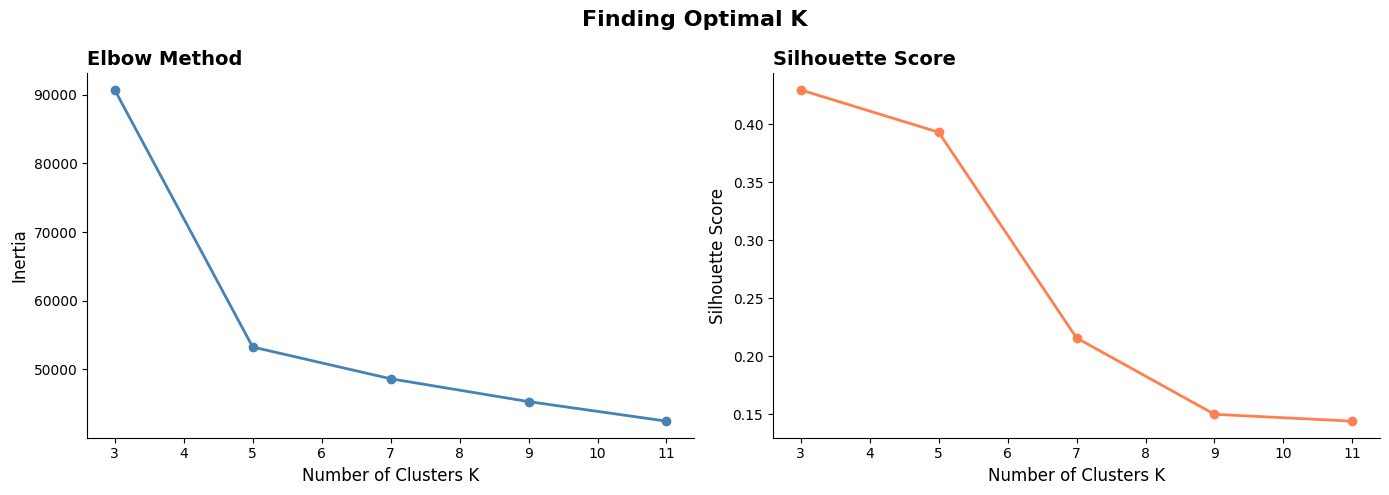

In [16]:
inertias = []
sil_scores = []
K_range = range(3, 12,2)

for k in K_range:
    km = KMeans(n_clusters=k,random_state=42,n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled,km.labels_))

fig, axes = plt.subplots(1,2,figsize=(14,5))

axes[0].plot(K_range, inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_xlabel('Number of Clusters K', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Elbow Method', fontweight='bold', fontsize=14, loc='left')
axes[0].spines[['right','top']].set_visible(False)

axes[1].plot(K_range, sil_scores, marker='o', color='coral', linewidth=2)
axes[1].set_xlabel('Number of Clusters K', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score', fontweight='bold', fontsize=14, loc='left')
axes[1].spines[['right','top']].set_visible(False)

plt.suptitle('Finding Optimal K', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## **Train**

In [17]:
optimal_k = 5
model = KMeans(n_clusters=optimal_k,random_state=42,n_init=10)
model.fit(X_scaled)
print(f"Model trained with K={optimal_k} ✅")


Model trained with K=5 ✅


## **Labels**

In [18]:
df_copy['cluster'] = model.labels_
df_copy['cluster'].value_counts().sort_index()

cluster
0    8980
1    6995
2    5996
3    4238
4    3794
Name: count, dtype: int64

## **lables Summery**

In [19]:
df_copy.groupby('cluster')[X.columns].mean().sort_index().reset_index()

,cluster,pm25,pm10,no2_ppb,co_ppm,so2_ppb,o3_ppb,wind_speed_kmh,humidity_pct,temperature_c,aqi
0,0,45.016026,85.154709,45.156216,1.202155,11.989788,54.653028,9.958516,59.914233,28.026169,115.366778
1,1,148.442430,277.128626,89.298419,3.471362,44.511654,30.335643,6.009495,69.665138,31.944986,277.040785
2,2,84.467698,158.388597,119.127091,2.768537,19.780595,64.574853,4.109955,55.018953,34.889933,193.659605
3,3,12.795201,26.402612,15.961517,0.420720,3.282362,35.084330,20.605904,45.026083,23.266055,43.758053
4,4,13.032227,27.200095,16.049191,0.427072,3.285994,35.127812,14.479494,45.218289,20.592865,44.425938


## **Chart**

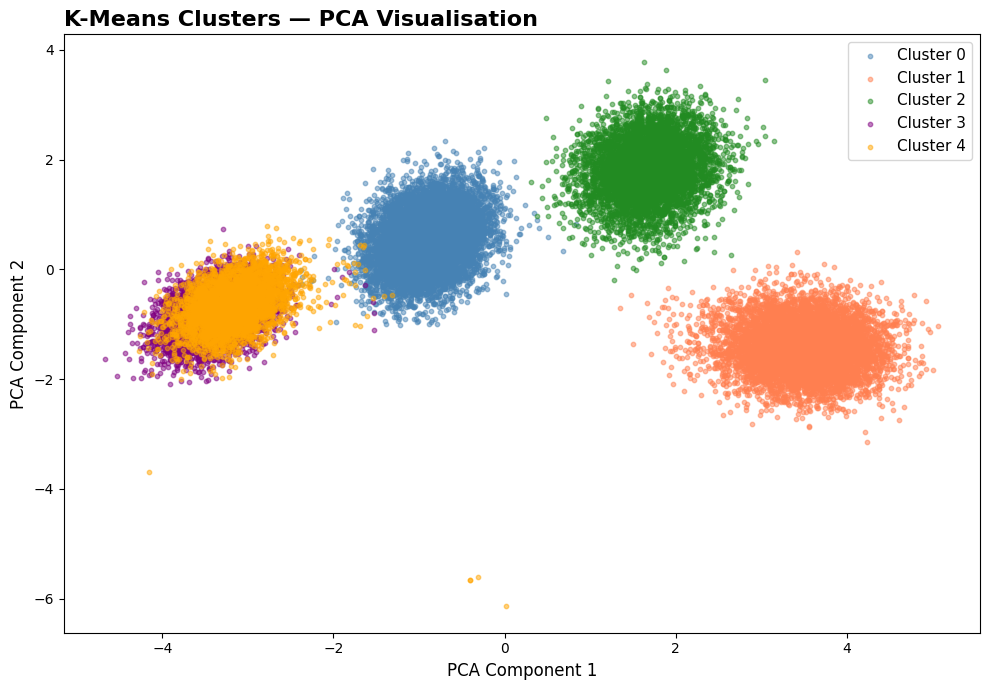

In [20]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
colors = ['steelblue', 'coral', 'forestgreen', 'purple', 'orange']

for cluster_id in range(optimal_k):
    mask = model.labels_ == cluster_id
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[cluster_id], label=f'Cluster {cluster_id}',
                alpha=0.5, s=10)

plt.xlabel('PCA Component 1', fontsize=12)
plt.ylabel('PCA Component 2', fontsize=12)
plt.title('K-Means Clusters — PCA Visualisation',
          fontweight='bold', fontsize=16, loc='left')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

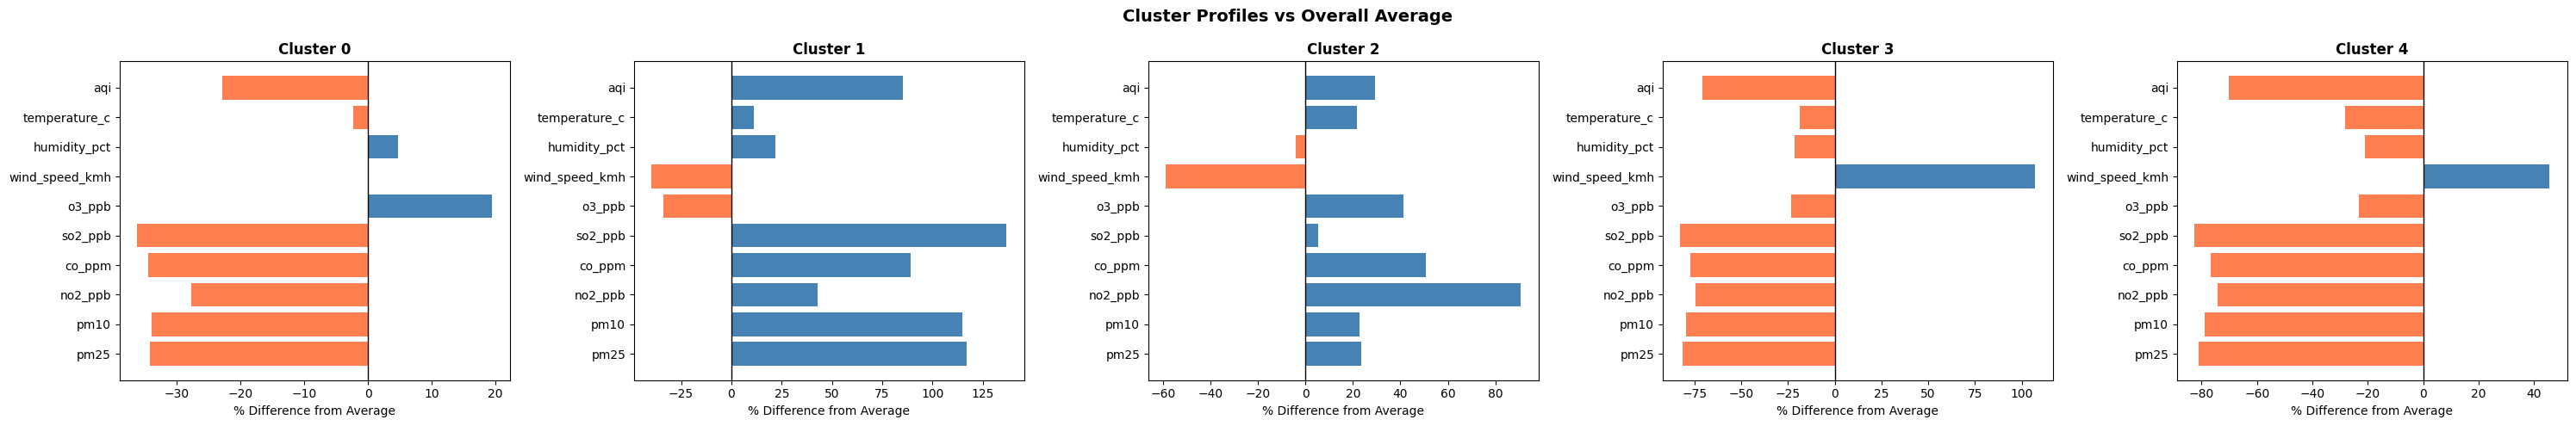

In [21]:
fig, axes = plt.subplots(1, optimal_k, figsize=(6*optimal_k, 5))

for i, ax in enumerate(axes):
    cluster_means = df_copy[df_copy['cluster']==i][X.columns].mean()
    overall_means = df_copy[X.columns].mean()
    diff = ((cluster_means - overall_means) / overall_means * 100).round(1)
    
    colors = ['coral' if v < 0 else 'steelblue' for v in diff]
    ax.barh(diff.index, diff.values, color=colors)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_title(f'Cluster {i}', fontweight='bold')
    ax.set_xlabel('% Difference from Average')

plt.suptitle('Cluster Profiles vs Overall Average',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()